Importing libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk
from scipy.stats import pearsonr

# Setup environment
nltk.download('vader_lexicon', quiet=True)
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 7]
print("Environment Ready!")

Environment Ready!


Data alignment

In [3]:
print("Loading and cleaning news data...")
df_news = pd.read_csv('Data/raw_analyst_ratings.csv')

# Clean dates
df_news['normalized_date'] = pd.to_datetime(
    df_news['date'], 
    format='ISO8601', 
    utc=True
).dt.tz_localize(None).dt.normalize()

# Clean ticker strings
df_news['stock'] = df_news['stock'].astype(str).str.strip().str.upper()


df_news['stock'] = df_news['stock'].replace({'FB': 'META'})

print(f"News data loaded. Unique tickers in news: {df_news['stock'].nunique()}")

Loading and cleaning news data...
News data loaded. Unique tickers in news: 6204


In [4]:
print("Generating master trading calendar...")
all_files = glob.glob('Data/*.csv') 
stock_files = [f for f in all_files if 'raw_analyst_ratings' not in f]

all_trading_days = set()

for file in stock_files:
    df_temp = pd.read_csv(file)
    df_temp.columns = [c.capitalize() for c in df_temp.columns]
    if 'Date' in df_temp.columns:
        dates = pd.to_datetime(df_temp['Date']).dt.normalize().dropna()
        all_trading_days.update(dates)

master_calendar = pd.DataFrame({'trading_date': sorted(list(all_trading_days))})

# Roll-forward news dates to the next trading day
unique_news_dates = pd.DataFrame({'news_date': df_news['normalized_date'].unique()}).sort_values('news_date')
date_mapping = pd.merge_asof(
    unique_news_dates, 
    master_calendar, 
    left_on='news_date', 
    right_on='trading_date', 
    direction='forward'
)

df_news = df_news.merge(date_mapping, left_on='normalized_date', right_on='news_date', how='left')
df_news = df_news.drop(columns=['news_date'])
print("Date alignment mapping complete.")

Generating master trading calendar...
Date alignment mapping complete.


In [5]:
all_aligned_datasets = {}

print("Merging news with stock datasets...")
for file in stock_files:
    ticker = os.path.splitext(os.path.basename(file))[0].upper()
    
    df_stock = pd.read_csv(file)
    df_stock.columns = [c.capitalize() for c in df_stock.columns]
    df_stock['Date'] = pd.to_datetime(df_stock['Date']).dt.normalize()
    
    # Filter news for this ticker (Now includes FB news if ticker is META)
    df_news_ticker = df_news[df_news['stock'] == ticker].copy()
    
    if df_news_ticker.empty:
        print(f"  ⚠️ No news found for {ticker}")
        continue

    # Inner merge ensures we only keep news that successfully mapped to a trading day
    df_final = pd.merge(
        df_news_ticker, 
        df_stock, 
        left_on='trading_date', 
        right_on='Date', 
        how='inner'
    )
    
    if not df_final.empty:
        all_aligned_datasets[ticker] = df_final
        print(f"  -> Successfully aligned {ticker}: {len(df_final)} rows.")
    else:
        print(f"  ⚠️ {ticker} matched news but no date overlap found.")

Merging news with stock datasets...
  -> Successfully aligned AMZN: 278 rows.
  -> Successfully aligned NVDA: 3146 rows.
  -> Successfully aligned META: 380 rows.
  -> Successfully aligned GOOG: 1199 rows.
  -> Successfully aligned AAPL: 441 rows.


Sentiment Analysis & Returns Calculation

The sentiment analysis is done using NLTK VADER. Because VADER understands the difference in intensity,it is good at  understanding context than Textblob.

In [6]:
sia = SentimentIntensityAnalyzer()
print("\nCalculating sentiment and returns...")

for ticker, df in all_aligned_datasets.items():
    # Sentiment Score
    df['sentiment_score'] = df['headline'].apply(lambda x: sia.polarity_scores(str(x))['compound'])
    
    # Daily Returns
    df = df.sort_values('trading_date').reset_index(drop=True)
    close_col = [col for col in df.columns if col.lower() == 'close'][0]
    df['daily_return'] = df[close_col].pct_change() * 100
    df['daily_return'] = df['daily_return'].fillna(0)
    
    all_aligned_datasets[ticker] = df

print("Calculations complete.")


Calculating sentiment and returns...
Calculations complete.


Aggregation and Final Plots

Starting Visualization...



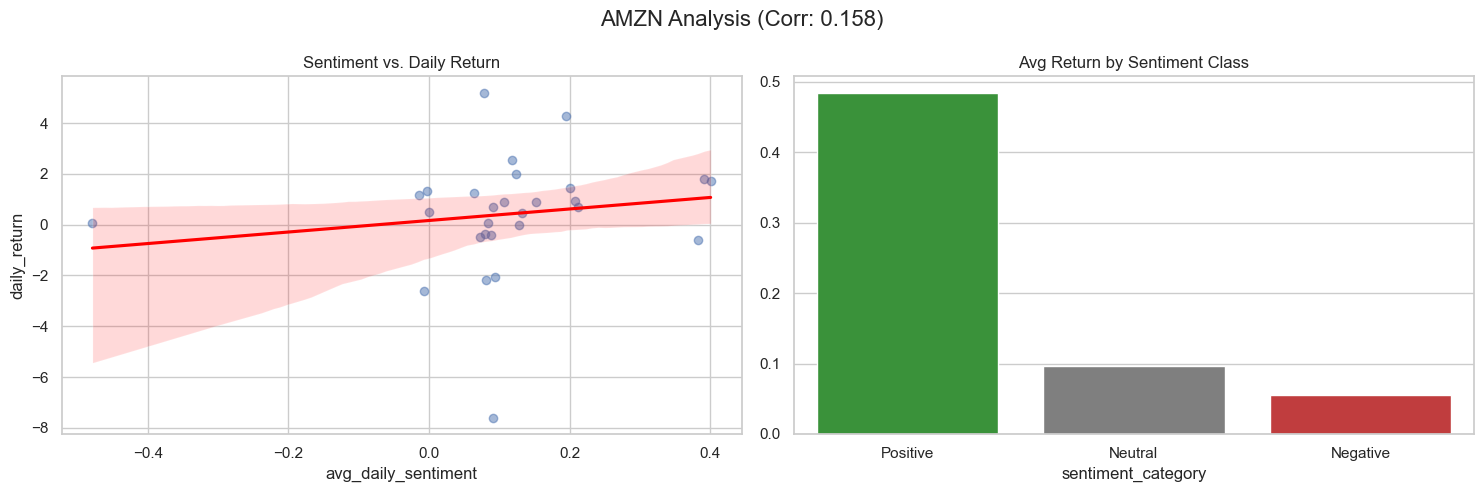

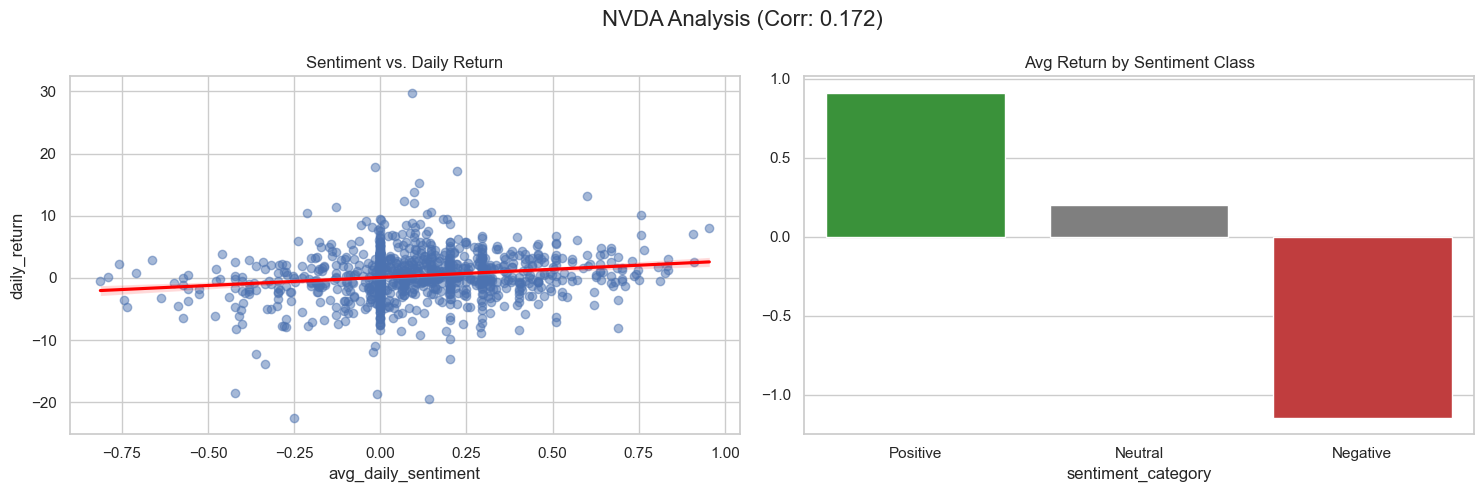

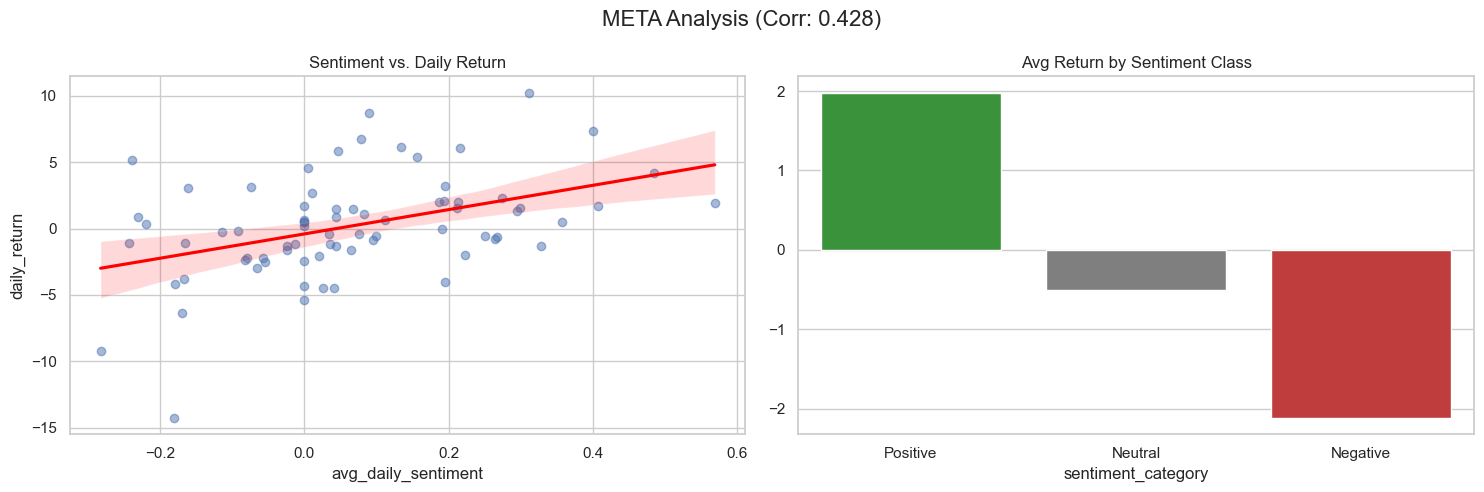

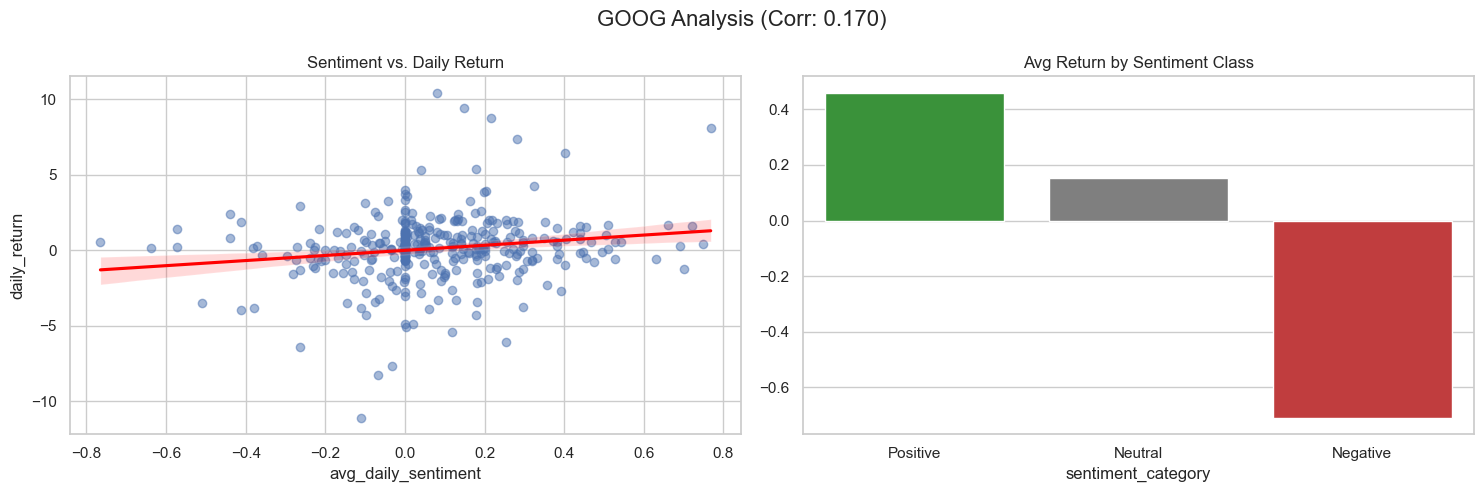

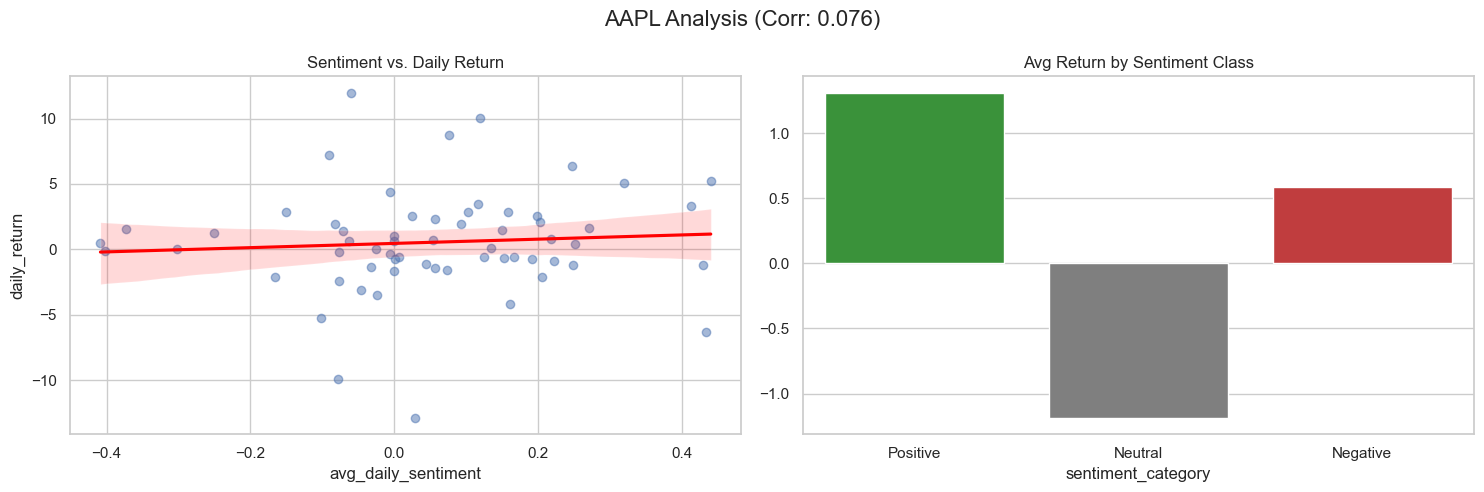

In [7]:
print("Starting Visualization...\n")

for ticker, df_merged in all_aligned_datasets.items():
    # Aggregate to one row per day
    df_daily = df_merged.groupby('trading_date').agg({
        'sentiment_score': 'mean',
        'daily_return': 'first'
    }).reset_index().rename(columns={'sentiment_score': 'avg_daily_sentiment'})
    
    if len(df_daily) < 5:
        print(f"Skipping {ticker}: Not enough data.")
        continue

    # Correlation
    corr_coef, p_val = pearsonr(df_daily['avg_daily_sentiment'], df_daily['daily_return'])

    # Category classification
    conditions = [(df_daily['avg_daily_sentiment'] > 0.05), (df_daily['avg_daily_sentiment'] < -0.05)]
    df_daily['sentiment_category'] = np.select(conditions, ['Positive', 'Negative'], default='Neutral')
    cat_returns = df_daily.groupby('sentiment_category')['daily_return'].mean().reindex(['Positive', 'Neutral', 'Negative'])

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    fig.suptitle(f'{ticker} Analysis (Corr: {corr_coef:.3f})', fontsize=16)

    sns.regplot(ax=axes[0], data=df_daily, x='avg_daily_sentiment', y='daily_return', scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
    axes[0].set_title('Sentiment vs. Daily Return')

    sns.barplot(ax=axes[1], x=cat_returns.index, y=cat_returns.values, palette=['#2ca02c', '#7f7f7f', '#d62728'], hue=cat_returns.index, legend=False)
    axes[1].set_title('Avg Return by Sentiment Class')
    
    plt.tight_layout()
    plt.show()

Interpret Results


Strength and Direction: 

All five stocks showed a positive correlation. This confirms the basic theory that better news generally leads to better price performance.

But all correlations were very weak (<0.1). This proves that news headlines are only a tiny "signal" in a very "noisy" market.

Lag Effects (The Speed Limit):

News travels instantly. By the time we aggregate a whole day's news and compare it to the closing price, the "trade" is over. This is the biggest reason why correlations are low. The market reacts to a headline in 30 seconds, not 8 hours.

Confounding Factors (The External Noise):

Macro-Economics: Inflation data, Federal Reserve interest rate hikes, and geopolitical events (like wars or trade bans) move these Big Tech stocks much more than a single analyst rating does.

Market Beta: These five stocks (AAPL, AMZN, GOOG, META, NVDA) make up a huge part of the S&P 500. Often, they move just because the entire market is moving, regardless of their own news.